# Class Notes: Clustering and Text Analytics (24 June 2026)

Two halves today. First unsupervised learning (clustering), then text analytics (NLP).

Topics covered:
1. Unsupervised learning and the goal of clustering
2. Requirements and approaches (agglomerative, divisive)
3. K means clustering and the elbow method
4. Hierarchical clustering, dendrograms, linkage methods
5. DBSCAN
6. Evaluation of clustering (internal and external, silhouette, Jaccard)
7. Text analytics and NLP basics (NLTK, spaCy)
8. Tokenization, stopwords, POS tagging, chunking
9. Stemming and lemmatization
10. Named entity recognition and BIO tagging
11. Word vectorization: bag of words, TF-IDF, n-grams
12. Neural approaches: CBOW, Word2Vec, RNN, LSTM, GRU, attention, Transformers

---

# PART A: UNSUPERVISED LEARNING (CLUSTERING)

In [1]:

# Setup for this notebook
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)


## 1. Unsupervised Learning and the Goal of Clustering

Everything so far had a labeled target (a price, a yes/no, a class). Unsupervised learning drops the labels.

**Unsupervised learning finds structure in data that has no target column.**

**Clustering is the task of grouping rows so that rows in the same group are similar to each other and different from rows in other groups.**

Plainly: no one tells the model the right answer, it just organizes the data into natural piles based on how close the points are.

Applications: customer segmentation, grouping documents by topic, image compression, anomaly detection (a point in no cluster is suspicious).

## 2. Main Requirements and Approaches

For clustering to work you need a **distance measure** (usually Euclidean distance) so "similar" has a meaning, and features on comparable scales, which is why scaling matters here just like it did for logistic regression.

Two broad approaches to building clusters:

- **Agglomerative (bottom up)**: start with every point as its own cluster, then repeatedly merge the two closest clusters.
- **Divisive (top down)**: start with all points in one cluster, then repeatedly split.

Agglomerative is the common one and is the basis of hierarchical clustering below.

## 3. K Means Clustering

**K means partitions the data into k clusters, each represented by its centroid (the mean of its points), by minimizing the total distance from points to their assigned centroid.**

Plainly: you pick how many groups k you want, and the algorithm shuffles points and centers around until each point belongs to its nearest center.

### Algorithm steps

```
1. Choose k, the number of clusters.
2. Initialize k centroids (often random points).
3. ASSIGN: put each point in the cluster of its nearest centroid.
4. UPDATE: move each centroid to the mean of the points assigned to it.
5. Repeat ASSIGN and UPDATE until the centroids stop moving.
```

Worked example, one iteration on 1D data `[2, 3, 4, 10, 11, 12]` with poor initial centroids c1=2 and c2=4:

```
ASSIGN: 2,3 go to c1;  4,10,11,12 go to c2
UPDATE: new c1 = mean(2,3)          = 2.5
        new c2 = mean(4,10,11,12)   = 9.25
```

(Verified in Python.) After more iterations the centroids settle near 3 and 11, cleanly separating the two natural groups. Note that a bad start can bias the first step, which is why the improved initializer k means++ is normally used.

### Elbow Method

K means needs you to pick k, but how. The elbow method helps.

**The elbow method runs k means for a range of k values, plots the within cluster sum of squares (inertia) against k, and looks for the "elbow" where the curve stops dropping sharply.**

```
 inertia
   |  \
   |   \
   |    \
   |     \_____  <- elbow here, pick this k
   |          \____
   +------------------- k
     1  2  3  4  5  6
```

Plainly: adding clusters always lowers inertia, but past the right k the gains flatten, and that bend is a good choice for k.

assignments: [(np.int64(2), 'c1'), (np.int64(3), 'c1'), (np.int64(4), 'c2'), (np.int64(10), 'c2'), (np.int64(11), 'c2'), (np.int64(12), 'c2')]
new c1 = mean([2, 3]) = 2.5
new c2 = mean([4, 10, 11, 12]) = 9.25


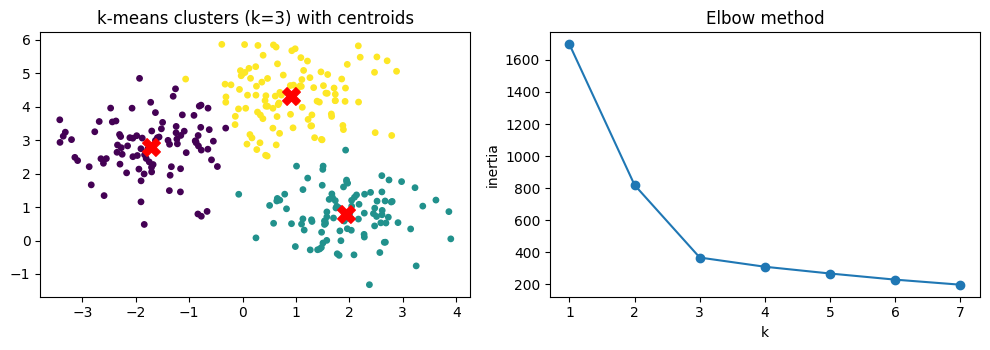

In [2]:
# one k-means iteration by hand on 1D data with poor initial centroids
data = np.array([2, 3, 4, 10, 11, 12], dtype=float)
c1, c2 = 2.0, 4.0
assign = ["c1" if abs(x - c1) <= abs(x - c2) else "c2" for x in data]
g1 = [x for x, a in zip(data, assign) if a == "c1"]
g2 = [x for x, a in zip(data, assign) if a == "c2"]
print("assignments:", list(zip(data.astype(int), assign)))
print(f"new c1 = mean({[int(v) for v in g1]}) = {np.mean(g1)}")
print(f"new c2 = mean({[int(v) for v in g2]}) = {np.mean(g2)}")

# k-means with scikit-learn on 2D blobs, plus the elbow curve
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

X, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.8, random_state=0)
km = KMeans(n_clusters=3, n_init=10, random_state=0).fit(X)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].scatter(X[:, 0], X[:, 1], c=km.labels_, cmap="viridis", s=15)
ax[0].scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
              c="red", marker="X", s=160)
ax[0].set_title("k-means clusters (k=3) with centroids")

inertia = [KMeans(n_clusters=k, n_init=10, random_state=0).fit(X).inertia_
           for k in range(1, 8)]
ax[1].plot(range(1, 8), inertia, "o-")
ax[1].set_xlabel("k"); ax[1].set_ylabel("inertia"); ax[1].set_title("Elbow method")
plt.tight_layout(); plt.show()

## 4. Hierarchical Clustering

**Hierarchical clustering builds a tree of nested clusters instead of a single flat partition, so you do not have to fix k in advance.**

Plainly: it merges points into bigger and bigger groups (agglomerative), recording the whole history, and you cut the tree wherever you want to get your clusters.

### Algorithm steps (agglomerative)

```
1. Start with each point as its own cluster.
2. Compute distances between all clusters.
3. Merge the two closest clusters.
4. Update distances.
5. Repeat until one cluster remains, recording every merge.
```

### Dendrograms

**A dendrogram is the tree diagram that records the merge history, with the height of each join showing how far apart the merged clusters were.**

```
height
  |        ______|______
  |       |             |
  |    ___|___        __|__
  |   |       |      |     |
  |  _|_     _|_     |     |
  | |   |   |   |    |     |
    a   b   c   d    e     f

cut the dendrogram with a horizontal line;
the number of vertical lines it crosses is your number of clusters
```

Plainly: read it bottom to top, low joins are tight groups, and where you slice horizontally decides how many clusters you end up with.

### Linkage methods

Linkage defines the distance between two clusters (not two points):

- **Single linkage**: distance between the two closest points, one from each cluster. Can chain clusters into long straggly shapes.
- **Complete linkage**: distance between the two farthest points. Produces tight, compact clusters.
- (Average and Ward linkage also exist; Ward, which merges to minimize variance increase, is a common default.)

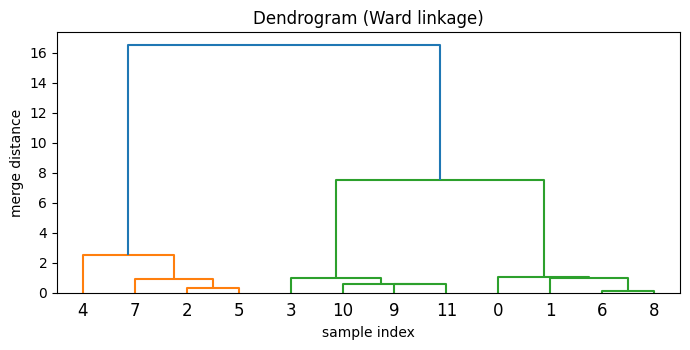

In [3]:
# a dendrogram from agglomerative (Ward) linkage on a small sample
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.datasets import make_blobs

Xs, _ = make_blobs(n_samples=12, centers=3, cluster_std=0.6, random_state=2)
Z = linkage(Xs, method="ward")
plt.figure(figsize=(7, 3.6))
dendrogram(Z)
plt.title("Dendrogram (Ward linkage)")
plt.xlabel("sample index"); plt.ylabel("merge distance")
plt.tight_layout(); plt.show()

## 5. DBSCAN

K means and hierarchical struggle with odd shapes and noise. DBSCAN handles both.

**DBSCAN (Density Based Spatial Clustering of Applications with Noise) groups points that are packed closely together and marks points in low density regions as noise.**

Plainly: it grows clusters wherever points are dense, and it does not need you to pick k, and it can label outliers as noise instead of forcing them into a cluster.

Two parameters:

- **epsilon (eps)**: the radius around a point that counts as its neighborhood.
- **min_points**: the minimum number of neighbors (within eps) a point needs to be considered dense.

Three kinds of point:

- **Core point**: has at least min_points neighbors within eps.
- **Border point**: within eps of a core point but does not have enough neighbors itself.
- **Noise point**: neither core nor border, left unclustered.

### Algorithm steps

```
1. For each point, count neighbors within eps.
2. Mark points with >= min_points neighbors as CORE.
3. Connect core points that are within eps of each other into one cluster.
4. Attach border points to a nearby core point's cluster.
5. Anything left over is NOISE.
```

Plainly: dense blobs become clusters no matter their shape, and lonely points become noise. The catch is that eps and min_points need tuning and it struggles when clusters have very different densities.

clusters found = 2
noise points   = 0


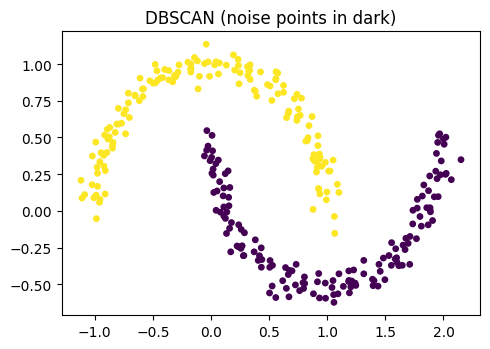

In [4]:
# DBSCAN finds non-round clusters and labels sparse points as noise
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN

Xm, _ = make_moons(n_samples=300, noise=0.06, random_state=0)
labels = DBSCAN(eps=0.2, min_samples=5).fit_predict(Xm)
n_noise = np.sum(labels == -1)
print(f"clusters found = {len(set(labels)) - (1 if -1 in labels else 0)}")
print(f"noise points   = {n_noise}")

plt.figure(figsize=(5, 3.6))
plt.scatter(Xm[:, 0], Xm[:, 1], c=labels, cmap="viridis", s=15)
plt.title("DBSCAN (noise points in dark)"); plt.tight_layout(); plt.show()

## 6. Evaluation of Clustering

There is no label to check against directly, so evaluation splits into two kinds.

**External evaluation compares the clusters to known ground truth labels. Internal evaluation judges the clusters using only the data itself (how tight and how separated they are).**

### Silhouette Score (internal)

**The silhouette score for a point is `(b - a) / max(a, b)`, where a is its mean distance to points in its own cluster (cohesion) and b is its mean distance to the nearest other cluster (separation).**

- **Cohesion (a)**: how close the point is to its own cluster. Smaller is better.
- **Separation (b)**: how far the point is from the nearest other cluster. Larger is better.

```
Silhouette ranges from -1 to 1:
  near  1  -> well inside its cluster, far from others (good)
  near  0  -> sitting on a boundary between clusters
  near -1  -> probably in the wrong cluster
```

Worked example, a point with a=1.5 and b=4.0:

```
silhouette = (4.0 - 1.5) / max(1.5, 4.0) = 2.5 / 4.0 = 0.6250
```

(Verified in Python.) A score of 0.625 means the point is comfortably in its cluster. Averaging over all points gives an overall clustering score, and you can use it to pick k, like the elbow method.

### Jaccard Coefficient (external)

**The Jaccard coefficient measures overlap between two sets as `intersection size / union size`.**

Worked example, cluster A = {1,2,3,4} vs true group B = {3,4,5}:

```
Jaccard = |A intersect B| / |A union B| = |{3,4}| / |{1,2,3,4,5}| = 2/5 = 0.4000
```

(Verified in Python.) 1.0 is a perfect match, 0 is no overlap. Used when you do have ground truth to compare against.

### Confusion Matrix (external)

The same confusion matrix idea from classification can be reused for clustering with known labels, by counting pairs of points that are correctly placed together or apart, which feeds metrics like the Jaccard coefficient above.

---

# PART B: TEXT ANALYTICS (NLP)

In [5]:
# silhouette for one point by hand, then the average score for the k-means result
a, b = 1.5, 4.0
print(f"one point: a={a}, b={b} -> silhouette = (b-a)/max(a,b) = {(b - a) / max(a, b):.4f}")

from sklearn.metrics import silhouette_score
print(f"average silhouette of the k-means blobs = {silhouette_score(X, km.labels_):.4f}")

# Jaccard coefficient between a predicted cluster and a true group
A, B = {1, 2, 3, 4}, {3, 4, 5}
print(f"\nJaccard(A,B) = |A∩B|/|A∪B| = {len(A & B)}/{len(A | B)} = {len(A & B) / len(A | B):.4f}")

one point: a=1.5, b=4.0 -> silhouette = (b-a)/max(a,b) = 0.6250
average silhouette of the k-means blobs = 0.5571

Jaccard(A,B) = |A∩B|/|A∪B| = 2/5 = 0.4000


## 7. Text Analytics and NLP

Clustering worked on numbers. Text is not numbers, so the whole job of this half is turning language into numbers a model can use.

**Natural Language Processing (NLP) is the field of getting computers to work with human language: parsing it, understanding it, and generating it.**

Two standard Python libraries: **NLTK** (the classic teaching toolkit, lots of building blocks) and **spaCy** (faster, production oriented, with strong built in models).

## 8. Tokenization, Stopwords, POS Tagging, Chunking

### Tokenization

**Tokenization splits raw text into smaller units called tokens.**

- **Sentence tokenization**: split a paragraph into sentences.
- **Word tokenization**: split a sentence into words and punctuation.

Plainly: it is the first cut, turning one long string into a list of pieces the rest of the pipeline can handle.

### Stopwords

**Stopwords are extremely common words (the, is, and, of) that carry little meaning and are usually removed.**

Plainly: they appear everywhere, so they add noise without helping tell documents apart. Punctuation is dropped for the same reason.

### POS Tagging and Chunking

**Part of speech (POS) tagging labels each token with its grammatical role (noun, verb, adjective).**

**Chunking groups tagged tokens into larger phrases, for example collecting nouns under a single noun phrase node.**

Plainly: POS tagging says what each word is, chunking then bundles related words into meaningful phrases, which is a step toward pulling structure out of a sentence.

In [6]:
# simple whitespace tokenization and stopword removal (no external downloads)
text = "The quick brown fox is running over the lazy dog"
tokens = text.lower().split()
stopwords = {"the", "is", "over", "a", "an", "of", "and"}
filtered = [t for t in tokens if t not in stopwords]
print("tokens         :", tokens)
print("after stopwords:", filtered)

tokens         : ['the', 'quick', 'brown', 'fox', 'is', 'running', 'over', 'the', 'lazy', 'dog']
after stopwords: ['quick', 'brown', 'fox', 'running', 'lazy', 'dog']


## 9. Stemming and Lemmatization

Both cut words down to a base form so that "run," "running," and "ran" are treated as one thing, but they do it differently.

**Stemming chops word endings off using crude rules, and the result may not be a real word.**

**Lemmatization maps a word to its proper dictionary base form (its lemma) using vocabulary and grammar, so the result is always a real word.**

```
word        stemming        lemmatization
studies  -> studi           study
better   -> better          good
running  -> run             run
```

Plainly: stemming is fast and rough (it just hacks off suffixes), lemmatization is slower and correct (it knows "better" comes from "good").

Three common stemmers, increasing aggressiveness:

- **Porter stemmer**: the original, gentle, widely used.
- **Snowball stemmer**: an improved Porter (also called Porter2), supports several languages.
- **Lancaster stemmer**: the most aggressive, chops hardest, can over stem.

## 10. Named Entity Recognition

**Named entity recognition (NER) finds and labels real world entities in text, like people, organizations, locations, and dates.**

Plainly: it scans a sentence and tags the meaningful nouns with what kind of thing they are ("Apple" as an organization, "Tampa" as a location).

### The ambiguity issue

The same word can be different entities depending on context. "Apple" is a company in "Apple released a phone" but a fruit in "I ate an apple," and "Washington" can be a person, a city, or a state. NER has to use the surrounding words to decide.

### BIO tagging

**BIO tagging labels each token as B (beginning of an entity), I (inside an entity), or O (outside any entity), which lets multi word entities be captured.**

```
token:   Steve   Jobs   founded   Apple   in   California
tag:     B-PER   I-PER    O       B-ORG   O    B-LOC
```

Plainly: B marks where an entity starts, I continues it, O is everything else, so "Steve Jobs" is stitched together as one person.

## 11. Word Vectorization (Word Embedding)

This is the core of the half: turning words into numeric vectors.

**Word vectorization converts text into numeric vectors so machine learning models can process it.**

### One Hot Encoding

The simplest idea: each word becomes a vector that is all zeros except a single 1 at that word's position. It is simple but wasteful (huge sparse vectors) and it captures no meaning, since every word is equally distant from every other.

### Count Vectorizer and Bag of Words

**The bag of words model represents a document as the counts of each vocabulary word, ignoring word order.**

Plainly: it just tallies how many times each word appears, throwing away grammar and order (hence "bag").

Worked example, corpus of three docs with vocabulary `[cat, dog, ran, sat, the]`:

```
'the cat sat'  ->  [1, 0, 0, 1, 1]
'the dog sat'  ->  [0, 1, 0, 1, 1]
'the cat ran'  ->  [1, 0, 1, 0, 1]
```

(Verified in Python.) Each document is now a row of numbers. The weakness: "the" gets counted heavily everywhere despite meaning nothing, which TF-IDF fixes.

### n-gram model

Bag of words loses order. n-grams recover a little of it by treating short sequences as units.

**An n-gram is a contiguous run of n tokens.**

```
sentence: the cat sat on the mat
unigrams: the, cat, sat, on, the, mat
bigrams : the cat, cat sat, sat on, on the, the mat
trigrams: the cat sat, cat sat on, sat on the, on the mat
```

(Verified in Python.) Bigrams and trigrams capture phrases like "the cat," so a little context survives. **Skip grams** are a related idea (used in Word2Vec) where the pairs skip over words rather than being strictly adjacent.

### TF-IDF (Term Frequency, Inverse Document Frequency)

Bag of words overvalues common words. TF-IDF fixes that by down weighting words that appear in many documents.

**TF-IDF weights each word by how often it appears in a document (TF) times how rare it is across all documents (IDF).**

- **Term Frequency (TF)**: how often the word appears in this document. Higher means more important to this document.
- **Inverse Term Frequency (ITF)**: the plain idea that a word appearing very often loses importance, so its weight should move inversely to its frequency. This is the intuition, and note that "inverse term frequency" is often used loosely as another name for the inverse weighting step. In the actual TF-IDF formula the inverse part is measured across documents, which is the IDF below, so ITF is the concept and IDF is the version we compute.
- **Inverse Document Frequency (IDF)**: `log((1 + N) / (1 + df)) + 1` in the smoothed sklearn form, where N is the number of documents and df is how many documents contain the word. Rare words get a high IDF, words in every document get a low one.
- **TF times IDF**: multiply them, so a word scores high only if it is frequent here but rare elsewhere.

Worked example, same three doc corpus. Document frequencies and IDF:

```
word:  cat   dog   ran   sat   the
df  :   2     1     1     2     3
idf : 1.288 1.693 1.693 1.288 1.000   ("the" is in all 3 docs, so lowest idf)
```

Final L2 normalized TF-IDF matrix (matches scikit-learn exactly):

```
'the cat sat'  ->  [0.620, 0.000, 0.000, 0.620, 0.481]
'the dog sat'  ->  [0.000, 0.720, 0.000, 0.548, 0.425]
'the cat ran'  ->  [0.548, 0.000, 0.720, 0.000, 0.425]
```

(Verified in Python against sklearn.) Notice "the" now has the smallest weight in every row even though it appears in all of them, which is exactly the goal.

In [7]:
# bag of words, n-grams, and TF-IDF on a tiny 3-document corpus
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

corpus = ["the cat sat", "the dog sat", "the cat ran"]

bow = CountVectorizer()
counts = bow.fit_transform(corpus).toarray()
print("vocabulary:", bow.get_feature_names_out().tolist())
print("bag of words counts:\n", counts)

# n-grams from one sentence
s = "the cat sat on the mat".split()
print("\nunigrams:", s)
print("bigrams :", [f"{s[i]} {s[i+1]}" for i in range(len(s) - 1)])
print("trigrams:", [f"{s[i]} {s[i+1]} {s[i+2]}" for i in range(len(s) - 2)])

tfidf = TfidfVectorizer()
M = tfidf.fit_transform(corpus).toarray()
print("\nTF-IDF matrix (L2 normalized):")
print("cols:", tfidf.get_feature_names_out().tolist())
print(np.round(M, 3))

vocabulary: ['cat', 'dog', 'ran', 'sat', 'the']
bag of words counts:
 [[1 0 0 1 1]
 [0 1 0 1 1]
 [1 0 1 0 1]]

unigrams: ['the', 'cat', 'sat', 'on', 'the', 'mat']
bigrams : ['the cat', 'cat sat', 'sat on', 'on the', 'the mat']
trigrams: ['the cat sat', 'cat sat on', 'sat on the', 'on the mat']

TF-IDF matrix (L2 normalized):
cols: ['cat', 'dog', 'ran', 'sat', 'the']
[[0.62  0.    0.    0.62  0.481]
 [0.    0.72  0.    0.548 0.425]
 [0.548 0.    0.72  0.    0.425]]


## 12. Neural Approaches

Count based vectors (bag of words, TF-IDF) still miss meaning, since "good" and "great" look unrelated. Neural embeddings fix that by learning vectors where similar words sit close together.

### CBOW and Word2Vec

**Word2Vec is a neural method that learns dense word vectors so that words used in similar contexts get similar vectors.**

It has two training styles:

- **CBOW (Continuous Bag of Words)**: predict the center word from its surrounding context words.
- **Skip gram**: the reverse, predict the surrounding context words from the center word.

Plainly: by learning to predict words from their neighbors, the model ends up placing "king" near "queen" and "good" near "great," so the vectors finally carry meaning. This is the payoff that one hot and bag of words could not give.

### RNN, LSTM, GRU

Text is a sequence, so we want models that read it in order and remember context.

- **RNN (Recurrent Neural Network)**: processes tokens one at a time, passing a hidden state forward so earlier words influence later ones. It struggles to remember long range context (the vanishing gradient problem).
- **LSTM (Long Short Term Memory)**: an RNN with gates that decide what to keep, forget, and output, so it holds context over longer sequences.
- **GRU (Gated Recurrent Unit)**: a simpler, faster LSTM with fewer gates, often similar in performance.

### Attention, Encoder Decoder, Transformers

**The attention mechanism lets a model look at all input tokens at once and weigh how much each one matters for the current output, instead of relying on a single passed along hidden state.**

Plainly: rather than squeezing a whole sentence into one memory vector, attention lets each output word look back at every input word and focus on the relevant ones.

The **encoder decoder** setup uses one stack to read the input and another to generate the output (as in translation), and attention connects them so the decoder can focus on the right input words.

**The Transformer architecture drops recurrence entirely and is built purely on self attention, so it processes the whole sequence in parallel.**

That parallelism is what makes it scale to huge datasets and is why Transformers power modern models like BERT and GPT. (This connects directly to the transformers notes already in the repo.)

---

## One line recap

Clustering finds groups in unlabeled data (K means for round clusters, hierarchical for a tree, DBSCAN for odd shapes and noise), and text analytics turns language into numbers (bag of words and TF-IDF for counts, Word2Vec and Transformers for meaning) so the same machine learning tools can be applied to text.